Hola **Carmen**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
--
</div>

# Proyecto 9

En este proyecto se busca optimizar los gastos de marketing de la empresa Showz__

## Parte 1. Preparar datos

In [1]:
#Cargar líbrerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#Cargar archivos
visits=pd.read_csv('/datasets/visits_log_us.csv')
orders=pd.read_csv('/datasets/orders_log_us.csv')
costs=pd.read_csv('/datasets/costs_us.csv')

In [3]:
#Explorar archivo
visits.head()

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [4]:
#Explorar archivo
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [5]:
#Cambiar a formato datetime
visits['End Ts']=pd.to_datetime(visits['End Ts'],format='%Y-%m-%d %H:%M:%S')
visits['Start Ts']=pd.to_datetime(visits['Start Ts'],format='%Y-%m-%d %H:%M:%S')

In [6]:
#Renombrar columnas
visits=visits.rename(columns={'Device':'device',
                             'End Ts':'end_ts',
                             'Source Id':'source_id',
                             'Start Ts':'star_ts',
                              'Uid':'uid'})

In [7]:
#Explorar archivo
orders.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [8]:
#Explorar archivo
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [9]:
#Cambiar a formato datetime
orders['Buy Ts']=pd.to_datetime(orders['Buy Ts'],format='%Y-%m-%d %H:%M:%S')

In [10]:
#Renombrar columnas
orders=orders.rename(columns={'Buy Ts':'buy_ts',
                             'Revenue':'revenue',
                             'Uid':'uid'})

In [11]:
#Explorar archivo
costs.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [12]:
#Explorar archivo
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [13]:
#Cambiar a formato datetime
costs['dt']=pd.to_datetime(costs['dt'])

In [14]:
costs['dt'].min(), costs['dt'].max()

(Timestamp('2017-06-01 00:00:00'), Timestamp('2018-05-31 00:00:00'))

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo con el análisis inicial de tus dataset, siempre es importante primero revisar la calidad de los datos y el tipo de los mismos antes de pasar a cualquier análisis
</div>

## Parte 2. Informes y métricas

### 1 Visitas

#### 2.1.1 ¿Cuántas personas lo usan cada día, semana y mes?

In [15]:
#Cambiar a formato datetime
visits['session_date']=visits['star_ts'].dt.date
visits['session_week']=visits['star_ts'].dt.isocalendar().week
visits['session_month']=visits['star_ts'].dt.to_period('M').dt.start_time

In [16]:
#Día
visits_dau_total=visits.groupby('session_date').agg({'uid':'unique'})
print(f'Las visitas diarias de usuarios unicos son:',visits_dau_total.count())

Las visitas diarias de usuarios unicos son: uid    364
dtype: int64


In [17]:
#Semana
visits_wau_total=visits.groupby('session_week').agg({'uid':'nunique'})
print(f'Las visitas semanales de usuarios unicos son:',visits_wau_total.count())

Las visitas semanales de usuarios unicos son: uid    52
dtype: int64


In [18]:
#Mes
visits_mau_total=visits.groupby('session_month').agg({'uid':'nunique'})
print(f'Las visitas mensuales de usuarios unicos son:',visits_mau_total.count())

Las visitas mensuales de usuarios unicos son: uid    12
dtype: int64


#### 2.1.2 ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).

In [19]:
#Sesiones por usuario
sessions_per_day=visits.groupby('session_date').agg({'uid':['count','nunique']})
sessions_per_day.columns=['n_sessions','n_users']
sessions_per_day['session_per_user']=sessions_per_day['n_sessions']/sessions_per_day['n_users']
sessions_per_day.head()

,n_sessions,n_users,session_per_user
session_date,,,
2017-06-01,664,605,1.097521
2017-06-02,658,608,1.082237
2017-06-03,477,445,1.071910
2017-06-04,510,476,1.071429
2017-06-05,893,820,1.089024


In [20]:
print('Promedio de sesiones por usuario {} al día'.format(round(sessions_per_day['session_per_user'].mean(),2)))

Promedio de sesiones por usuario 1.08 al día


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para complementar mejor lo que se muestra de estos cálculos podrías utilizar gráficas de líneas ya que al tratarse de datos temporales se pueden identificar tendencias
</div>

#### 2.1.3 ¿Cuál es la duración de cada sesión?

In [21]:
#Duración de las visitas en segundos
visits['sessions_duration_sec']=(visits['end_ts']-visits['star_ts']).dt.seconds
print('Estadisticas de la duración de visitas:',
      visits['sessions_duration_sec'].describe())

Estadisticas de la duración de visitas: count    359400.000000
mean        643.506489
std        1016.334786
min           0.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       84480.000000
Name: sessions_duration_sec, dtype: float64


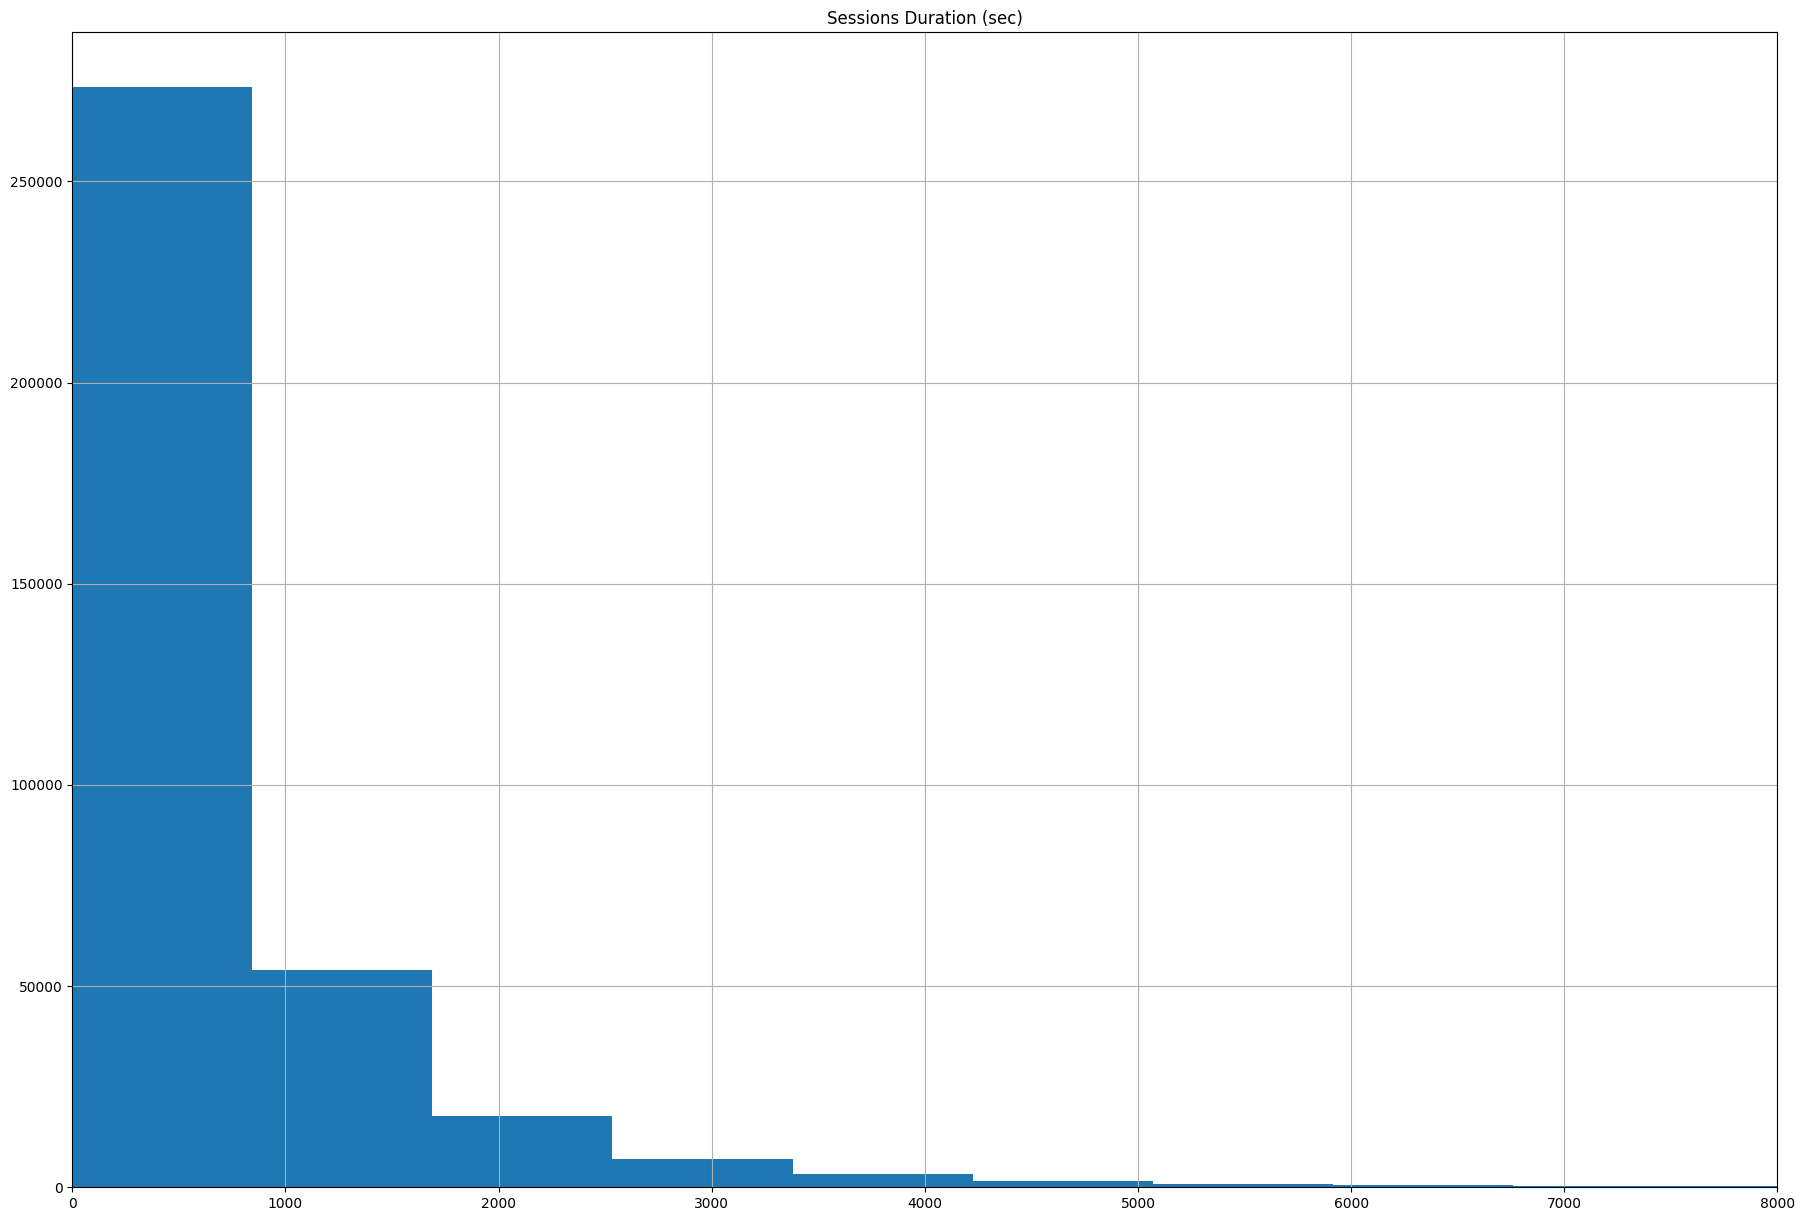

In [22]:
#Grafica de duración de sesiones en segundos
plt.figure(figsize=(22,15))
visits['sessions_duration_sec'].hist(bins=100).set(title='Sessions Duration (sec)')
plt.xlim(0,8000)
plt.show()

#### 2.1.4 ¿Con qué frecuencia los usuarios regresan?

In [23]:
#Sesiones iniciales
first_visits=visits.groupby('uid').agg({'star_ts':'min'}).reset_index()
first_visits.columns=('uid','first_sessions_start_ts')
first_visits.head()

,uid,first_sessions_start_ts
0,11863502262781,2018-03-01 17:27:00
1,49537067089222,2018-02-06 15:55:00
2,297729379853735,2017-06-07 18:47:00
3,313578113262317,2017-09-18 22:49:00
4,325320750514679,2017-09-30 14:29:00


In [24]:
#Sesiones mensuales
first_visits['first_sessions_dt']=first_visits['first_sessions_start_ts'].dt.date
first_visits['first_sessions_month']=first_visits['first_sessions_start_ts'].dt.to_period('M').dt.start_time

In [25]:
#Fusionar datos
visits_complete=pd.merge(first_visits,visits, on='uid')
visits_complete.head()

,uid,first_sessions_start_ts,first_sessions_dt,first_sessions_month,device,end_ts,source_id,star_ts,session_date,session_week,session_month,sessions_duration_sec
0,11863502262781,2018-03-01 17:27:00,2018-03-01,2018-03-01,touch,2018-03-01 17:33:00,3,2018-03-01 17:27:00,2018-03-01,9,2018-03-01,360
1,49537067089222,2018-02-06 15:55:00,2018-02-06,2018-02-01,touch,2018-02-06 15:57:00,2,2018-02-06 15:55:00,2018-02-06,6,2018-02-01,120
2,297729379853735,2017-06-07 18:47:00,2017-06-07,2017-06-01,desktop,2017-06-07 18:48:00,3,2017-06-07 18:47:00,2017-06-07,23,2017-06-01,60
3,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,desktop,2018-03-11 17:29:00,2,2018-03-11 17:23:00,2018-03-11,10,2018-03-01,360
4,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,desktop,2017-09-18 23:07:00,2,2017-09-18 22:49:00,2017-09-18,38,2017-09-01,1080


In [26]:
#Calcular el ciclo de vida
visits_complete['life_circle']=(visits_complete['session_month'].dt.month-visits_complete['first_sessions_month'].dt.month)
visits_complete['life_circle'] += 12*(visits_complete['session_month'].dt.year-visits_complete['first_sessions_month'].dt.year)
visits_complete.head()

,uid,first_sessions_start_ts,first_sessions_dt,first_sessions_month,device,end_ts,source_id,star_ts,session_date,session_week,session_month,sessions_duration_sec,life_circle
0,11863502262781,2018-03-01 17:27:00,2018-03-01,2018-03-01,touch,2018-03-01 17:33:00,3,2018-03-01 17:27:00,2018-03-01,9,2018-03-01,360,0
1,49537067089222,2018-02-06 15:55:00,2018-02-06,2018-02-01,touch,2018-02-06 15:57:00,2,2018-02-06 15:55:00,2018-02-06,6,2018-02-01,120,0
2,297729379853735,2017-06-07 18:47:00,2017-06-07,2017-06-01,desktop,2017-06-07 18:48:00,3,2017-06-07 18:47:00,2017-06-07,23,2017-06-01,60,0
3,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,desktop,2018-03-11 17:29:00,2,2018-03-11 17:23:00,2018-03-11,10,2018-03-01,360,6
4,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,desktop,2017-09-18 23:07:00,2,2017-09-18 22:49:00,2017-09-18,38,2017-09-01,1080,0


In [27]:
#Analisis de cohorts
cohorts_visits=visits_complete.pivot_table(
    index='first_sessions_month',
    columns='life_circle',
    values='uid',
    aggfunc='nunique'
)
cohorts_visits.fillna('')

life_circle,0,1,2,3,4,5,6,7,8,9,10,11
first_sessions_month,,,,,,,,,,,,
2017-06-01,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0,766.0,694.0,674.0,539.0,596.0
2017-07-01,13140.0,737.0,674.0,738.0,765.0,633.0,596.0,601.0,510.0,376.0,361.0,
2017-08-01,10181.0,783.0,640.0,639.0,510.0,448.0,370.0,402.0,284.0,265.0,,
2017-09-01,16704.0,1428.0,1156.0,847.0,658.0,632.0,599.0,404.0,381.0,,,
2017-10-01,25977.0,2042.0,1357.0,1012.0,890.0,837.0,555.0,529.0,,,,
2017-11-01,27248.0,2133.0,1202.0,1054.0,919.0,638.0,594.0,,,,,
2017-12-01,25268.0,1410.0,960.0,786.0,512.0,481.0,,,,,,
2018-01-01,22624.0,1351.0,890.0,565.0,458.0,,,,,,,
2018-02-01,22197.0,1267.0,565.0,446.0,,,,,,,,


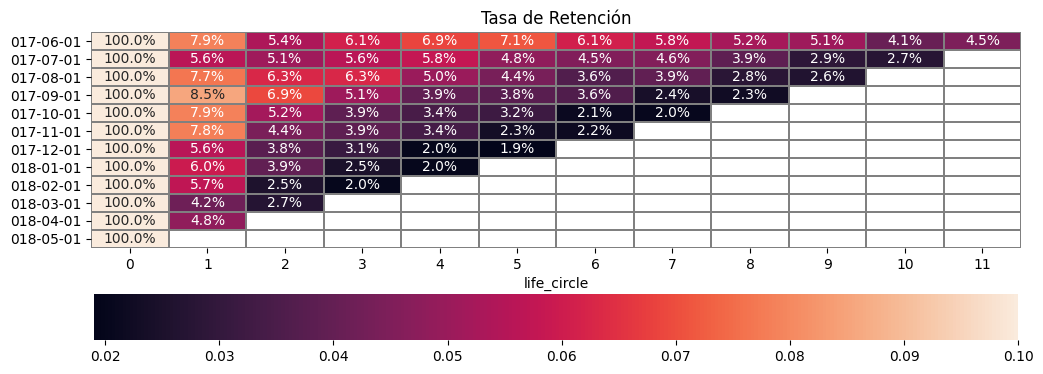

In [28]:
#Tasa de retención
#Porcentaje de los clientes que regresan
retention=pd.DataFrame()

for col in cohorts_visits.columns:
    retention=pd.concat([retention, cohorts_visits[col]/cohorts_visits[0]], axis=1)
retention.columns=cohorts_visits.columns
retention.index=[str(x)[1:10] for x in retention.index]

plt.figure(figsize=(12,4))
sns.heatmap(retention, annot=True, fmt='.1%', linewidths=1, linecolor='grey',
            vmax=0.1,cbar_kws={'orientation':'horizontal'}).set(title='Tasa de Retención')
plt.show()

En el mapa de calor se observa los porcentajes de clientes que regresan en cada cohort (12 cohorts),
va desde el 8.5% al 1.9%. 

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien realizado el análisis hasta esta sección, tienes gráficas claras y resultados muy bien explicados con lo que haz redactado luego de mostrar cada gráfica o cálculo, buen trabajo!
</div>

### 2 Ventas

#### 2.2.1 Cuándo empieza la gente a comprar? 

In [29]:
#Agregar día y mes
orders['buy_date']=orders['buy_ts'].dt.date
orders['buy_month']=orders['buy_ts'].dt.to_period('M')
orders.head()

,buy_ts,revenue,uid,buy_date,buy_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,2017-06


In [30]:
#Primeras comprars
first_orders=orders.groupby('uid').agg({'buy_ts':'min'}).reset_index()
first_orders.columns=('uid','first_order_ts')
first_orders['first_order_dt']=first_orders['first_order_ts'].dt.date
first_orders['first_order_month']=first_orders['first_order_ts'].dt.to_period('M')
first_orders.head()

,uid,first_order_ts,first_order_dt,first_order_month
0,313578113262317,2018-01-03 21:51:00,2018-01-03,2018-01
1,1575281904278712,2017-06-03 10:13:00,2017-06-03,2017-06
2,2429014661409475,2017-10-11 18:33:00,2017-10-11,2017-10
3,2464366381792757,2018-01-28 15:54:00,2018-01-28,2018-01
4,2551852515556206,2017-11-24 10:14:00,2017-11-24,2017-11


In [31]:
#Fusionar datos
buyers=pd.merge(first_visits,first_orders, on='uid')
buyers.head()

,uid,first_sessions_start_ts,first_sessions_dt,first_sessions_month,first_order_ts,first_order_dt,first_order_month
0,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,2018-01-03 21:51:00,2018-01-03,2018-01
1,1575281904278712,2017-06-03 10:13:00,2017-06-03,2017-06-01,2017-06-03 10:13:00,2017-06-03,2017-06
2,2429014661409475,2017-10-11 17:14:00,2017-10-11,2017-10-01,2017-10-11 18:33:00,2017-10-11,2017-10
3,2464366381792757,2018-01-27 20:10:00,2018-01-27,2018-01-01,2018-01-28 15:54:00,2018-01-28,2018-01
4,2551852515556206,2017-11-24 10:14:00,2017-11-24,2017-11-01,2017-11-24 10:14:00,2017-11-24,2017-11


In [32]:
buyers['first_order_dt']=pd.to_datetime(buyers['first_order_dt'])
buyers['first_sessions_dt']=pd.to_datetime(buyers['first_sessions_dt'])

In [33]:
#Cuando comienza a comprar la gente
buyers['days_to_first_purchase'] = ((buyers['first_order_ts']-buyers['first_sessions_start_ts'])/
np.timedelta64(1,'D'))

In [34]:
buyers.describe()

,uid,days_to_first_purchase
count,3.652300e+04,36523.000000
mean,9.213152e+18,16.902900
std,5.324792e+18,47.072760
min,3.135781e+14,0.000000
25%,4.615081e+18,0.002778
50%,9.245161e+18,0.011111
75%,1.383709e+19,2.011806
max,1.844617e+19,363.294444


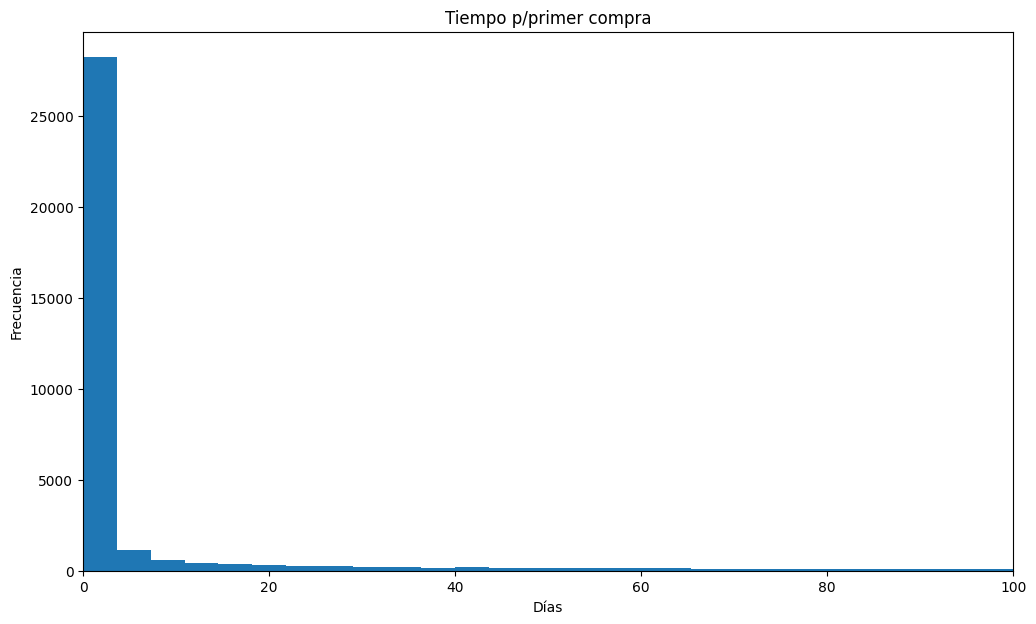

In [35]:
#Graficar
buyers['days_to_first_purchase'].plot(kind='hist', bins=100, figsize=(12,7)).set(title='Tiempo p/primer compra', xlabel='Días', ylabel='Frecuencia')
plt.xlim(0,100)
plt.show()

La mayoria de las personas comienzan a comprar en el momento de la primera visista y dentro de los 2 primeros días.

#### 2.2.2 ¿Cuántos pedidos hacen durante un período de tiempo dado?

In [36]:
#Encontrara numero de clientes para cada cohort(mes)
cohort_size_order=buyers.groupby('first_order_month').agg({'uid':'nunique'}).reset_index()
cohort_size_order.rename(columns={'uid':'n_buyers'}, inplace=True)
cohort_size_order

,first_order_month,n_buyers
0,2017-06,2023
1,2017-07,1923
2,2017-08,1370
3,2017-09,2581
4,2017-10,4340
5,2017-11,4081
6,2017-12,4383
7,2018-01,3373
8,2018-02,3651
9,2018-03,3533


In [37]:
#Agregar primer mes
cohort_orders_buyers=pd.merge(orders, buyers, how='inner', on='uid')
cohort_orders_buyers.head()
cohort_orders_buyers=cohort_orders_buyers.groupby(['first_order_month','buy_month']).agg({'revenue':'count'}).reset_index()
cohort_orders_buyers

,first_order_month,buy_month,revenue
0,2017-06,2017-06,2354
1,2017-06,2017-07,177
2,2017-06,2017-08,174
3,2017-06,2017-09,226
4,2017-06,2017-10,292
...,...,...,...
74,2018-03,2018-05,176
75,2018-04,2018-04,2495
76,2018-04,2018-05,195
77,2018-05,2018-05,3249


In [38]:
# Agregar ciclo de vida
cohort_orders_buyers['life_cycle']=(cohort_orders_buyers['buy_month'] - cohort_orders_buyers['first_order_month']).apply(lambda x:x.n)
cohort_orders_buyers.rename(columns={'revenue':'n_orders'}, inplace=True)
cohort_orders_buyers

,first_order_month,buy_month,n_orders,life_cycle
0,2017-06,2017-06,2354,0
1,2017-06,2017-07,177,1
2,2017-06,2017-08,174,2
3,2017-06,2017-09,226,3
4,2017-06,2017-10,292,4
...,...,...,...,...
74,2018-03,2018-05,176,2
75,2018-04,2018-04,2495,0
76,2018-04,2018-05,195,1
77,2018-05,2018-05,3249,0


In [39]:
cohort_orders_buyers_=cohort_orders_buyers.groupby('buy_month').agg({'n_orders':'sum'})

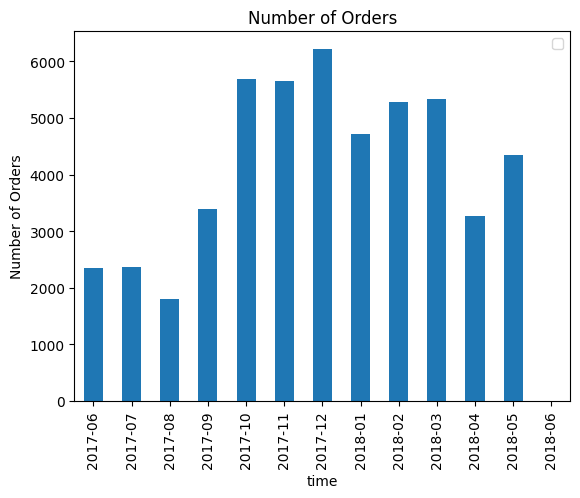

In [40]:
cohort_orders_buyers_.plot(kind='bar',
                          title='Number of Orders',
                          xlabel='time',
                          ylabel='Number of Orders')
plt.legend('')
plt.show()

Número de ordenes hechas por los clientes durante el tiempo (mensuales)

#### 2.2.3 ¿Cuál es el tamaño promedio de compra?

In [41]:
cohort_report=pd.merge(cohort_size_order,cohort_orders_buyers, on='first_order_month' )
cohort_report['orders_per_buyer']=cohort_report['n_orders']/cohort_report['n_buyers']
cohort_report.head()

,first_order_month,n_buyers,buy_month,n_orders,life_cycle,orders_per_buyer
0,2017-06,2023,2017-06,2354,0,1.163618
1,2017-06,2023,2017-07,177,1,0.087494
2,2017-06,2023,2017-08,174,2,0.086011
3,2017-06,2023,2017-09,226,3,0.111715
4,2017-06,2023,2017-10,292,4,0.144340


In [42]:
#Analisis
pivot_size_orders=cohort_report.pivot_table(
    index='first_order_month',
    columns='life_cycle',
    values='orders_per_buyer',
    aggfunc='sum'
).cumsum(axis=1)
pivot_size_orders.round(2).fillna('')

life_cycle,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,1.16,1.25,1.34,1.45,1.59,1.7,1.84,1.92,2.03,2.1,2.15,2.19
2017-07,1.14,1.19,1.25,1.31,1.34,1.39,1.42,1.44,1.47,1.49,1.51,
2017-08,1.12,1.2,1.27,1.33,1.39,1.44,1.47,1.53,1.56,1.6,,
2017-09,1.14,1.22,1.28,1.35,1.37,1.42,1.46,1.48,1.5,,,
2017-10,1.14,1.22,1.25,1.28,1.31,1.34,1.35,1.38,,,,
2017-11,1.18,1.28,1.32,1.37,1.41,1.42,1.45,,,,,
2017-12,1.15,1.21,1.26,1.3,1.32,1.34,,,,,,
2018-01,1.12,1.19,1.24,1.25,1.28,,,,,,,
2018-02,1.12,1.18,1.21,1.22,,,,,,,,


In [43]:
print('Promedio de compra por comprador', round(pivot_size_orders[5]).mean(),2)

Promedio de compra por comprador 1.1428571428571428 2


In [44]:
print('Promedio de compra:', round(orders['revenue'].mean(),2))

Promedio de compra: 5.0


In [45]:
orders.head()

,buy_ts,revenue,uid,buy_date,buy_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,2017-06


In [46]:
 pivot_orders=orders.pivot_table(
    index='buy_month',
    values='revenue',
    aggfunc='mean'
)
pivot_orders.head()

,revenue
buy_month,
2017-06,4.060106
2017-07,5.306589
2017-08,4.847139
2017-09,5.416448
2017-10,4.928280


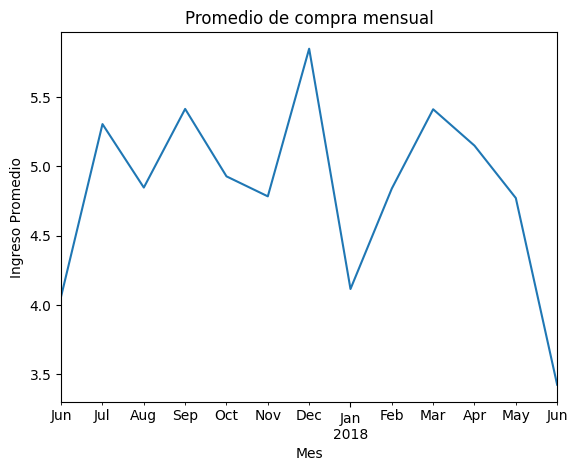

In [47]:
pivot_orders.plot(legend=None).set(title='Promedio de compra mensual', xlabel='Mes', ylabel='Ingreso Promedio')
plt.show();

Promedio de comprar mensual, siendo la temporada decembrina el mayor pico.

#### 2.2.4 ¿Cuánto dinero traen? (LTV) 

In [48]:
#Encontrar clientes para cada cohort (mes)
group_ltv=buyers.groupby('first_order_month').agg({'uid':'nunique'}).reset_index()
group_ltv.rename(columns={'uid':'n_buyers'}, inplace=True)
group_ltv

,first_order_month,n_buyers
0,2017-06,2023
1,2017-07,1923
2,2017-08,1370
3,2017-09,2581
4,2017-10,4340
5,2017-11,4081
6,2017-12,4383
7,2018-01,3373
8,2018-02,3651
9,2018-03,3533


In [49]:
#Agregando ingresos
merge_ltv=pd.merge(orders, buyers, how='inner', on='uid')
merge_ltv=merge_ltv.groupby(['first_order_month','buy_month']).agg({'revenue':'sum'}).reset_index()
merge_ltv

,first_order_month,buy_month,revenue
0,2017-06,2017-06,9557.49
1,2017-06,2017-07,981.82
2,2017-06,2017-08,885.34
3,2017-06,2017-09,1931.30
4,2017-06,2017-10,2068.58
...,...,...,...
74,2018-03,2018-05,1114.87
75,2018-04,2018-04,10600.69
76,2018-04,2018-05,1209.92
77,2018-05,2018-05,13925.76


In [50]:
#Ciclo de vida
merge_ltv['life_cycle']=(merge_ltv['buy_month'] - merge_ltv['first_order_month']).apply(lambda x:x.n)
merge_ltv

,first_order_month,buy_month,revenue,life_cycle
0,2017-06,2017-06,9557.49,0
1,2017-06,2017-07,981.82,1
2,2017-06,2017-08,885.34,2
3,2017-06,2017-09,1931.30,3
4,2017-06,2017-10,2068.58,4
...,...,...,...,...
74,2018-03,2018-05,1114.87,2
75,2018-04,2018-04,10600.69,0
76,2018-04,2018-05,1209.92,1
77,2018-05,2018-05,13925.76,0


In [51]:
#Clientes y LTV
cohort_ltv=pd.merge(group_ltv,merge_ltv, on='first_order_month' )
cohort_ltv['ltv']=cohort_ltv['revenue']/cohort_ltv['n_buyers']
cohort_ltv.head()

,first_order_month,n_buyers,buy_month,revenue,life_cycle,ltv
0,2017-06,2023,2017-06,9557.49,0,4.724414
1,2017-06,2023,2017-07,981.82,1,0.485329
2,2017-06,2023,2017-08,885.34,2,0.437637
3,2017-06,2023,2017-09,1931.30,3,0.954671
4,2017-06,2023,2017-10,2068.58,4,1.022531


In [52]:
cohorts_ltv_=cohort_ltv.pivot_table(
    index='first_order_month',
    columns='life_cycle',
    values='ltv',
    aggfunc='sum'
).cumsum(axis=1)

cohorts_ltv_.round(2).fillna('')

life_cycle,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,4.72,5.21,5.65,6.6,7.62,8.36,9.31,9.89,10.45,11.05,11.62,11.88
2017-07,6.01,6.35,6.97,7.33,7.5,7.66,7.78,7.92,8.08,8.23,8.39,
2017-08,5.28,5.75,6.21,6.6,7.09,7.38,7.59,7.99,8.28,8.47,,
2017-09,5.64,6.76,7.28,11.26,11.66,12.31,13.01,13.25,13.44,,,
2017-10,5.00,5.54,5.73,5.89,6.04,6.16,6.24,6.36,,,,
2017-11,5.15,5.55,5.75,6.08,6.23,6.28,6.4,,,,,
2017-12,4.74,5.0,5.92,6.99,7.3,7.64,,,,,,
2018-01,4.14,4.43,4.73,4.88,4.94,,,,,,,
2018-02,4.16,4.44,4.51,4.59,,,,,,,,


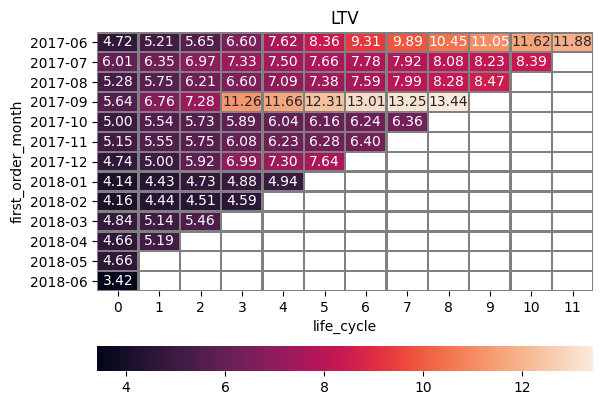

In [53]:
cohorts_ltv_.index=cohorts_ltv_.index.astype(str)
sns.heatmap(cohorts_ltv_, annot=True, fmt='.2f', linewidths=1, linecolor='grey',cbar_kws={'orientation':'horizontal'}
           ).set(title='LTV')
plt.show()

In [54]:
print('Promedio de LTV en 12 meses es:',round(cohorts_ltv_[5].mean(),2))
print('Es el ingreso promedio que un cliente esta aportando')

Promedio de LTV en 12 meses es: 7.97
Es el ingreso promedio que un cliente esta aportando


### 3 Marketing

#### 2.3.1 ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo) 

In [55]:
#Costo Total
print('Costo Total', costs['costs'].sum())

Costo Total 329131.62


In [56]:
#Extraer mes
costs['cost_month']=costs['dt'].dt.to_period('M')
costs.head()

,source_id,dt,costs,cost_month
0,1,2017-06-01,75.20,2017-06
1,1,2017-06-02,62.25,2017-06
2,1,2017-06-03,36.53,2017-06
3,1,2017-06-04,55.00,2017-06
4,1,2017-06-05,57.08,2017-06


,costs
cost_month,
2017-06,18015.00
2017-07,18240.59
2017-08,14790.54
2017-09,24368.91
2017-10,36322.88


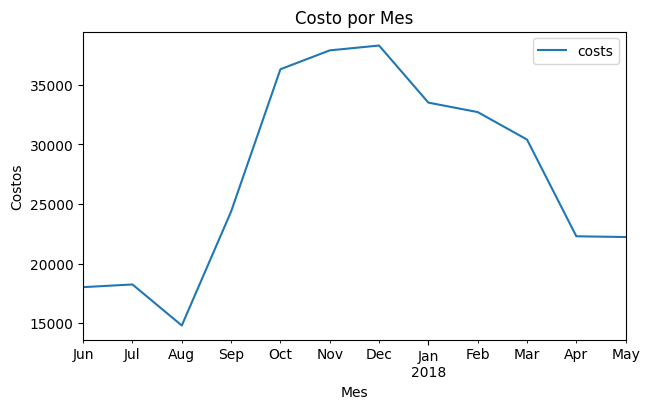

In [57]:
#Costo por mes
#A través del tiempo
costos_table=costs.pivot_table(
    index='cost_month',
    values='costs',
    aggfunc='sum'
)
display(costos_table.head())
costos_table.plot(figsize=(7,4), title='Costo por Mes', xlabel='Mes', ylabel='Costos')
plt.show();

In [58]:
print('Costos por fuente de adquisición')
costs_per_source=costs.groupby('source_id').agg({'costs':'sum'})
costs_per_source

Costos por fuente de adquisición


,costs
source_id,
1,20833.27
2,42806.04
3,141321.63
4,61073.60
5,51757.10
9,5517.49
10,5822.49


La fuente de aquisición más costosa es la número 3 y la más economica la número 9

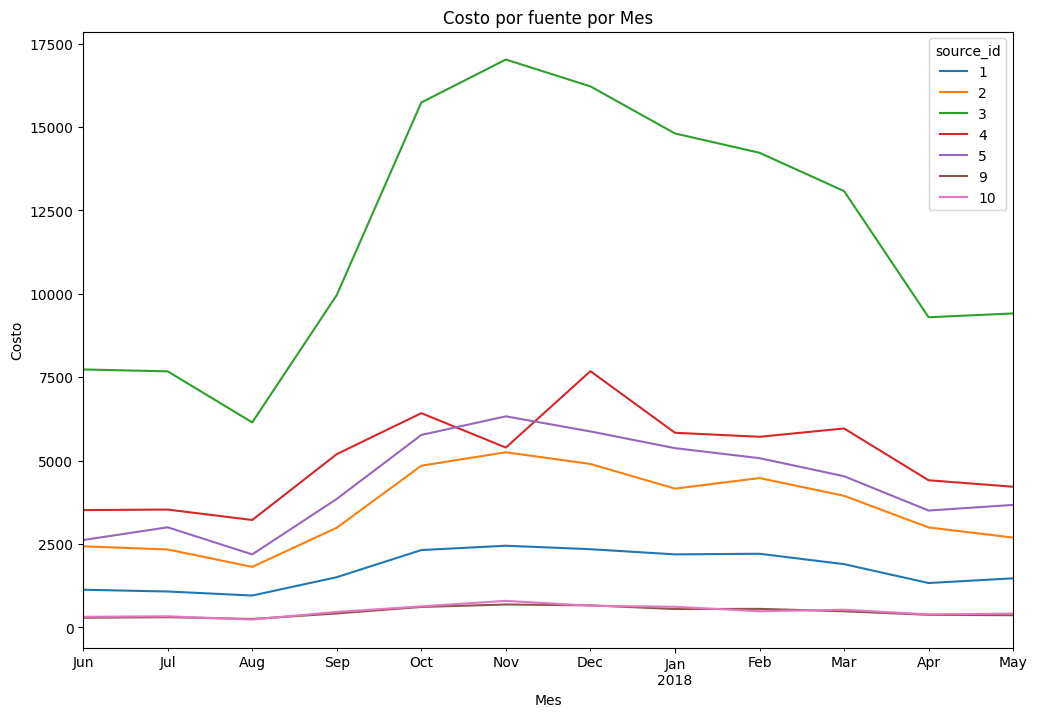

In [59]:
#Costo por fuente de adquisición
costs.pivot_table(
    index='cost_month',
    columns='source_id',
    values='costs',
    aggfunc='sum'
).plot(figsize=(12,8), title='Costo por fuente por Mes', xlabel='Mes', ylabel='Costo')
plt.show();

#### 2.3.2 ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

In [60]:
print('Costo de adquisición por cliente')
print('Promedio del CAC:', round(costs['costs'].sum()/orders['uid'].nunique(),2))

Costo de adquisición por cliente
Promedio del CAC: 9.01


In [61]:
#Calcular el cac mensual
cac_by_month=pd.merge(costs.groupby('cost_month').agg({'costs':'sum'}),
                     buyers.groupby('first_order_month').agg({'uid':'nunique'}),
                     left_index=True,
                     right_index=True)

In [62]:
cac_by_month['cac']=cac_by_month['costs']/cac_by_month['uid']
cac_by_month.head()

,costs,uid,cac
2017-06,18015.00,2023,8.905091
2017-07,18240.59,1923,9.485486
2017-08,14790.54,1370,10.796015
2017-09,24368.91,2581,9.441654
2017-10,36322.88,4340,8.369327


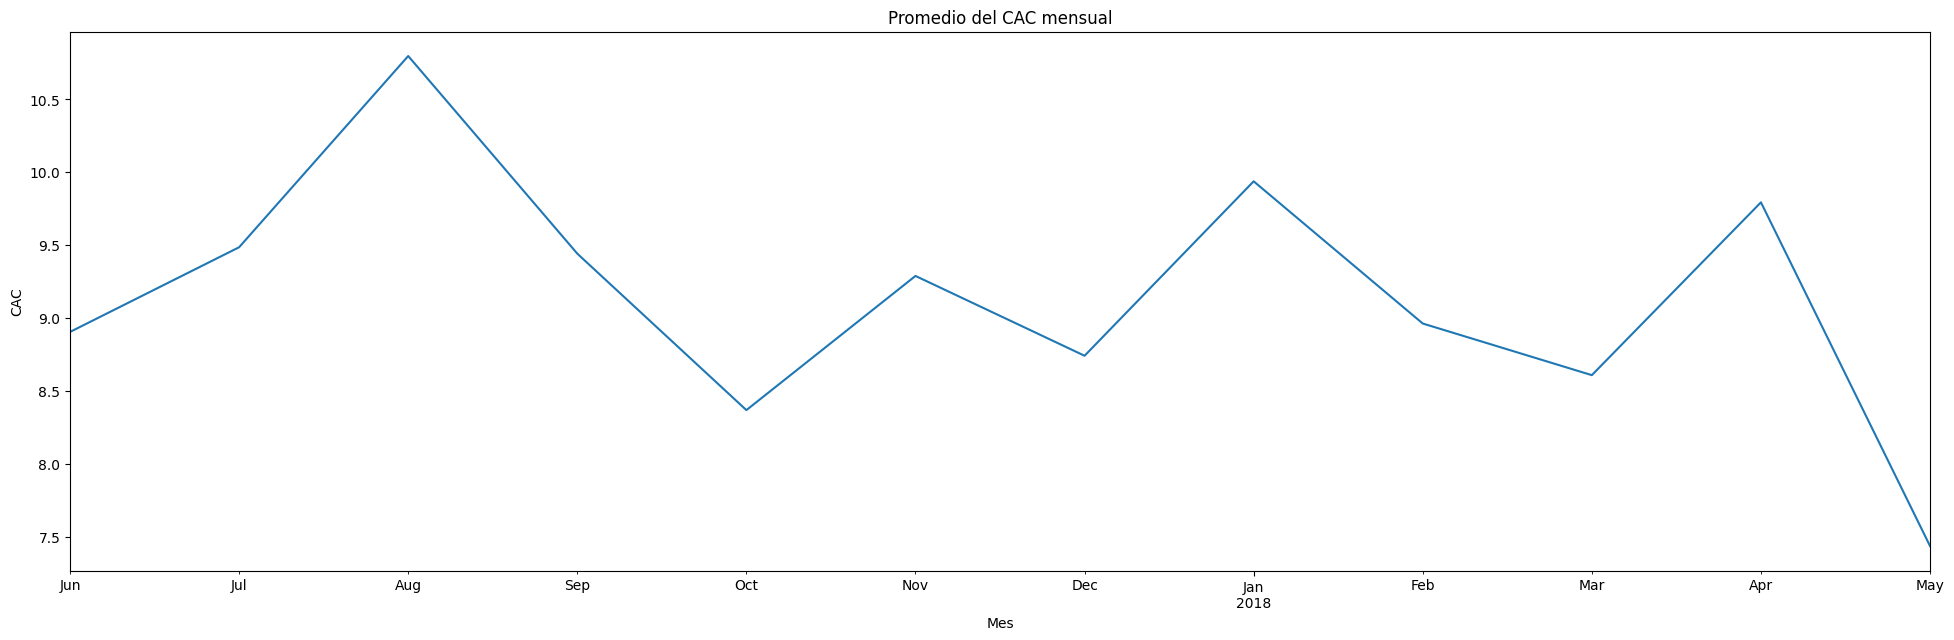

In [63]:
#Variación del cac mensual
cac_by_month['cac'].plot(figsize=(24,7), title='Promedio del CAC mensual', xlabel='Mes', ylabel='CAC')
plt.show();

In [64]:
#Calcular el cac por cliente por fuente de adquisición
#Visualizando los clientes
visits_complete.head()

,uid,first_sessions_start_ts,first_sessions_dt,first_sessions_month,device,end_ts,source_id,star_ts,session_date,session_week,session_month,sessions_duration_sec,life_circle
0,11863502262781,2018-03-01 17:27:00,2018-03-01,2018-03-01,touch,2018-03-01 17:33:00,3,2018-03-01 17:27:00,2018-03-01,9,2018-03-01,360,0
1,49537067089222,2018-02-06 15:55:00,2018-02-06,2018-02-01,touch,2018-02-06 15:57:00,2,2018-02-06 15:55:00,2018-02-06,6,2018-02-01,120,0
2,297729379853735,2017-06-07 18:47:00,2017-06-07,2017-06-01,desktop,2017-06-07 18:48:00,3,2017-06-07 18:47:00,2017-06-07,23,2017-06-01,60,0
3,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,desktop,2018-03-11 17:29:00,2,2018-03-11 17:23:00,2018-03-11,10,2018-03-01,360,6
4,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,desktop,2017-09-18 23:07:00,2,2017-09-18 22:49:00,2017-09-18,38,2017-09-01,1080,0


In [65]:
#Visitas de clientes por su primera sesión
users = visits_complete.sort_values('first_sessions_start_ts').groupby('uid').first()
users = users['source_id']
#unir costos(buyers)con id de usuarios y fuente de aquisisción (users)
compradores = pd.merge(buyers, users, left_on='uid', right_index=True)
compradores.head()

,uid,first_sessions_start_ts,first_sessions_dt,first_sessions_month,first_order_ts,first_order_dt,first_order_month,days_to_first_purchase,source_id
0,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,2018-01-03 21:51:00,2018-01-03,2018-01,106.959722,2
1,1575281904278712,2017-06-03 10:13:00,2017-06-03,2017-06-01,2017-06-03 10:13:00,2017-06-03,2017-06,0.000000,10
2,2429014661409475,2017-10-11 17:14:00,2017-10-11,2017-10-01,2017-10-11 18:33:00,2017-10-11,2017-10,0.054861,3
3,2464366381792757,2018-01-27 20:10:00,2018-01-27,2018-01-01,2018-01-28 15:54:00,2018-01-28,2018-01,0.822222,5
4,2551852515556206,2017-11-24 10:14:00,2017-11-24,2017-11-01,2017-11-24 10:14:00,2017-11-24,2017-11,0.000000,5


In [66]:
#Numero de compradores por cada día
compradores_diarios = compradores.groupby(['source_id','first_order_dt']).agg({'uid':'count'}).reset_index()
compradores_diarios.rename(columns={'uid':'n_buyers'}, inplace=True)
compradores_diarios.head()

,source_id,first_order_dt,n_buyers
0,1,2017-06-01,15
1,1,2017-06-02,11
2,1,2017-06-03,7
3,1,2017-06-04,4
4,1,2017-06-05,14


In [67]:
#Costo por fuente de adquisición
costos = pd.merge(compradores_diarios, costs, left_on=('source_id', 'first_order_dt'), right_on=('source_id','dt'))
costos['cac'] = costos['costs']/costos['n_buyers']
costos.head()

,source_id,first_order_dt,n_buyers,dt,costs,cost_month,cac
0,1,2017-06-01,15,2017-06-01,75.20,2017-06,5.013333
1,1,2017-06-02,11,2017-06-02,62.25,2017-06,5.659091
2,1,2017-06-03,7,2017-06-03,36.53,2017-06,5.218571
3,1,2017-06-04,4,2017-06-04,55.00,2017-06,13.750000
4,1,2017-06-05,14,2017-06-05,57.08,2017-06,4.077143


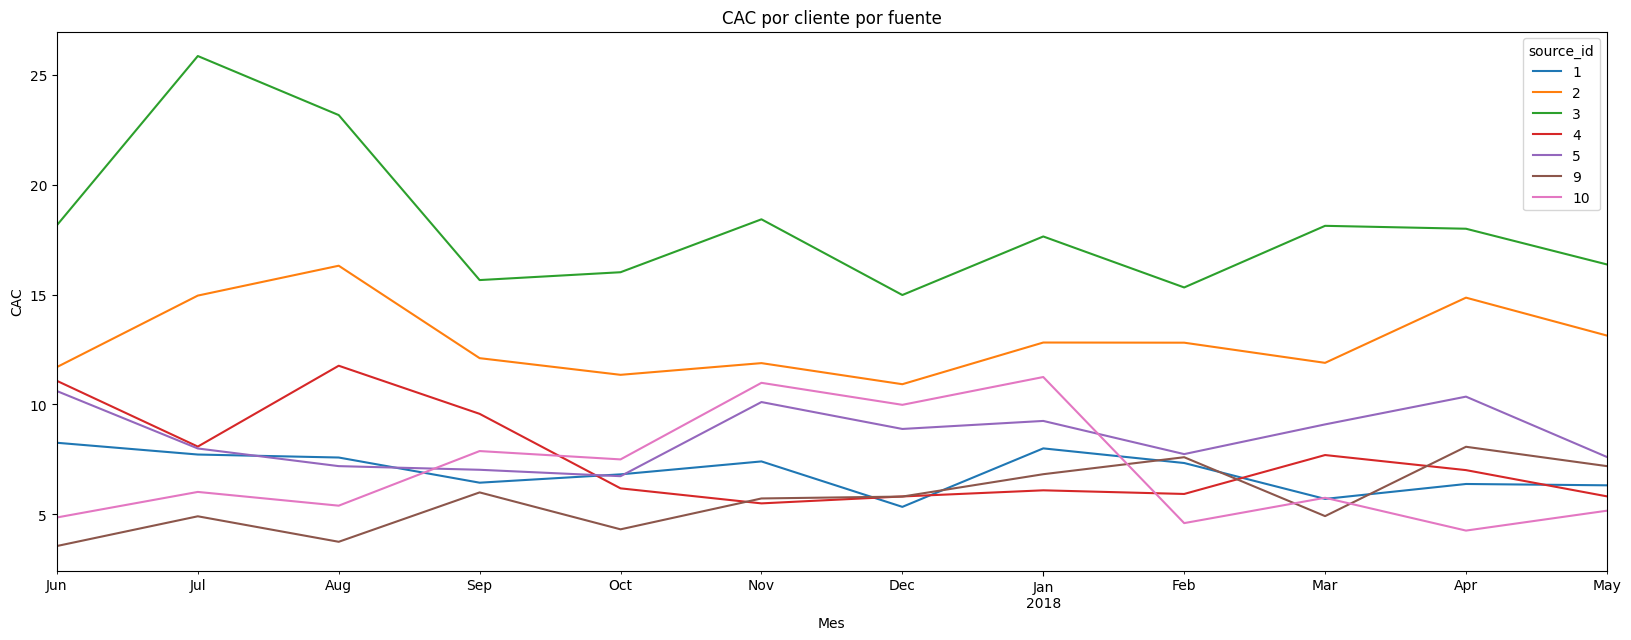

In [68]:
costos.pivot_table(
    index='cost_month',
    columns='source_id',
    values='cac',
    aggfunc='mean'
).plot(figsize=(20,7), title='CAC por cliente por fuente', xlabel='Mes', ylabel='CAC')
plt.show();

#### 2.3.3 ¿Cuán rentables eran las inversiones? (ROMI)

In [69]:
#Beneficio bruto
b_bruto = orders['revenue'].sum()
print('La ganancia neta es:',round(b_bruto.sum(),2))

La ganancia neta es: 252057.2


In [70]:
#Gasto total
gasto_total=costs['costs'].sum()
print('El gasto total es:',round(gasto_total.sum(),2))

El gasto total es: 329131.62


In [71]:
#ROMI
romi_total = (b_bruto/gasto_total)*100
romi_total

76.58249304639888

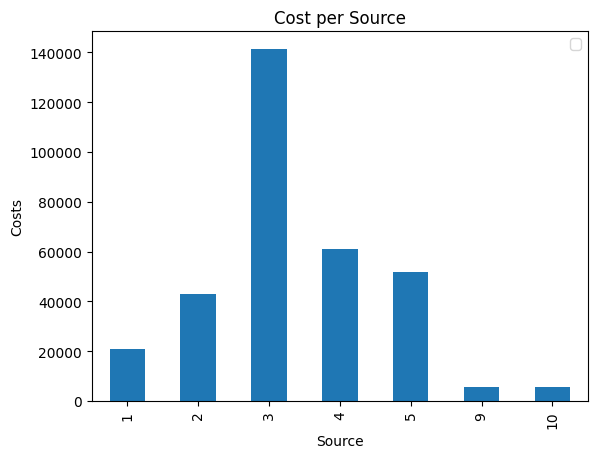

In [72]:
#Gastos por campaña
gasto_per_source = costs.groupby('source_id').agg({'costs':'sum'})

gasto_per_source.plot(kind='bar', title='Cost per Source', xlabel='Source', ylabel='Costs')
plt.legend('')
plt.show()

## Parte 3. Conclusión

### Visitas

Las visitas diarias de usuarios unicos fueron (dau) 364, las visitas semanales
de usuarios unicos fueron (wau) 52 y finalmente las visitas mensuales de usuarios
unicos fueron (mau) 12. En promedio hay 1.08 sesiones por usuario al día y la duración
promedio (en segundos) es de 643.5. El porcentaje con la que los usuarios regresan va del
1.9% al 8.5%.

### Ventas

Los usuarios usualmente compran desde el día de su primer visita y en los 2 días posteriores.
Durante la temporada decembrina se llego a alcanzar más de 6 000 ordenes (periodo mensual) y el mes mas bajo fue agosto con 1 800 ordenes aproximadamente. El promedio de compra por usuarios es de 1.14 ordenes y el ingreso promedio que un usuario aporta (LTV) es de $7.97 dolares.

### Marketing

Se gasto un total de $329 131.62 dolares y la fuente de adquisición más cara fue la número 3 con un costo de $141 321.64 dolares y la mas economica la número 9 con un costo de $55.49 dolares. El costo de adquisición más caro por cliente fue por la fuente número 1 y la mas economica la número 9. El ROMI total fue de 76.58%, esto es que obtuvo una ganancia del 76.58% del lo que invirtio en las campañas.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes un muy buen análisis de tu proyecto Carmen!

Siempre este tipo de análisis que son un poco más complejos hay que buscar cómo explicarlos de manera sencilla considerando la audiencia a la cual se va a presentar los resultados y es ahí donde las visualizaciones juegan un papel muy importante ya que con una visualización es mucho más fácil entender la explicación que con solo valores numéricos.

Muy buen trabajo, saludos!
</div>